# Heat-Death Time Series and Explanatory Count Model

This notebook replaces the old assault-count pipeline.

The original `combined_all.csv` file is missing, so the old `incident_count` target cannot be modeled honestly.  
This version uses the files currently available:

- `Heat Related 2021-2024.csv`
- `Heat Related 2024 EOY Coroner-dataset.xlsx`
- `Heat Deaths EOY 2025 (1).xlsx`

The goal is to build a clean heat-death time series, aggregate it weekly/monthly, optionally retrieve historical weather for Las Vegas, and fit count models:

- Poisson regression
- Negative Binomial regression, useful when the counts are overdispersed

The model should be treated as explanatory unless the dataset is expanded and validated further.


In [1]:
# Core imports
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Modeling imports
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

BASE_DIR = Path.cwd()

SEARCH_DIRS = [
    BASE_DIR,
    BASE_DIR / "Data",
    BASE_DIR / "Data" / "Heat Related Deaths",
    BASE_DIR.parent / "Data",
    BASE_DIR.parent / "Data" / "Heat Related Deaths",
]

def find_file(possible_names):
    for directory in SEARCH_DIRS:
        for name in possible_names:
            path = directory / name
            if path.exists():
                return path
    return None

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Current notebook folder:", BASE_DIR)


Current notebook folder: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact


## 1. Load and clean the heat-death files

The 2024 file overlaps with the 2021–2024 CSV, so we deduplicate by `Case #`.  
This prevents double-counting the same decedent/case.


In [2]:
heat_file_names = [
    "Heat Related 2021-2024.csv",
    "Heat Related 2024 EOY Coroner-dataset.xlsx",
    "Heat Deaths EOY 2025 (1).xlsx",
]

frames = []

for name in heat_file_names:
    path = find_file([name])

    if path is None:
        print(f"Missing file: {name}")
        continue

    if path.suffix.lower() == ".csv":
        temp_df = pd.read_csv(path, low_memory=False)
    else:
        temp_df = pd.read_excel(path)

    temp_df["source_file"] = path.name
    frames.append(temp_df)

    print(f"Loaded {path.name}: {len(temp_df):,} rows")

if not frames:
    raise FileNotFoundError("No heat-death source files were found.")

heat_raw = pd.concat(frames, ignore_index=True, sort=False)

required_cols = {"Case #", "Date of Death"}
missing_cols = required_cols - set(heat_raw.columns)

if missing_cols:
    raise KeyError(f"Missing required columns: {sorted(missing_cols)}")

print("\nRaw combined rows:", len(heat_raw))
print("Unique Case # values:", heat_raw["Case #"].nunique())
print("Duplicate Case # rows:", heat_raw.duplicated(subset=["Case #"]).sum())


Loaded Heat Related 2021-2024.csv: 1,165 rows
Loaded Heat Related 2024 EOY Coroner-dataset.xlsx: 472 rows
Loaded Heat Deaths EOY 2025 (1).xlsx: 263 rows

Raw combined rows: 1900
Unique Case # values: 1430
Duplicate Case # rows: 470


In [3]:
heat_df = heat_raw.copy()

# Parse date
heat_df["Date of Death"] = pd.to_datetime(heat_df["Date of Death"], errors="coerce")
heat_df = heat_df.dropna(subset=["Date of Death"]).copy()

# Deduplicate by Case #
before = len(heat_df)
heat_df = heat_df.drop_duplicates(subset=["Case #"], keep="first").copy()
after = len(heat_df)

heat_df["date"] = heat_df["Date of Death"].dt.normalize()
heat_df["year"] = heat_df["date"].dt.year
heat_df["month"] = heat_df["date"].dt.month

print(f"Rows after date cleanup + deduplication: {after:,}")
print(f"Duplicate records removed: {before - after:,}")
print(f"Date range: {heat_df['date'].min().date()} to {heat_df['date'].max().date()}")

display(heat_df.head())
display(heat_df.groupby("year").size().rename("heat_deaths_by_year").to_frame())


Rows after date cleanup + deduplication: 1,430
Duplicate records removed: 470
Date range: 2021-04-19 to 2025-10-27


,Case #,Name,Date of Death,Temperature,Age,Age Bin,Age Group,Race,Cause of Death A,Cause of Death A Category,OSC,State of Residence,Incident Location,Incident Location Zip Code,Incident Location Region,Incident Place Type,Incident Place Type Category,Death Location,Death Location Zip Code,Death Location Region,Death Place Type,Death Place Type Category,source_file,Cause of Death B,Cause of Death C,Cause of Death D,Manner of Death,How Injury Occurred,date,year,month
0,2024-08084,"Aviles, Irving Jr.",2024-11-25,57.92,40.0,40's,Adult (40–59),Black,Methamphetamine Toxicity,Methamphetamine-related,Environmental Heat Exposure,Unknown,NaN,NaN,Missing/Unknown,Outdoors,Outdoors/Public,NaN,NaN,Missing/Unknown,Desert,Outdoors/Public,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN,2024-11-25,2024,11
1,2024-07848,"Arakawa, Corinne",2024-11-15,62.96,71.0,70's,Senior (60+),Asian/Pacific Islander,Complications Of Thermal Cutaneous Injuries,Other / Unknown,Remote Environmental Hyperthermia And Sequelae...,Unknown,NaN,NaN,Missing/Unknown,Outdoors,Outdoors/Public,"1800 W Charleston Blvd, Las Vegas, NV 89102",89102.0,Urban Core,Hospital,Medical Facility,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN,2024-11-15,2024,11
2,2024-07944,"Johnson, Walter H.",2024-11-14,64.04,69.0,60's,Senior (60+),Black,Environmental Hyperthermia And Sequelae Thereof,Environmental Heat,Methamphetamine Toxicity,Nevada,NaN,NaN,Missing/Unknown,Home,Home/Residence,"1500 W Warm Springs Rd, Henderson, NV 89014",89014.0,Suburban SE,Hospice Inpatient,Other / Unknown,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN,2024-11-14,2024,11
3,2024-07044,"Davis, Fletcher",2024-10-09,96.98,40.0,40's,Adult (40–59),Black,Hyperthermia,Environmental Heat,Methamphetamine Use,Unknown,"2930 Las Vegas Blvd S, Las Vegas, NV 89109",89109.0,South/Strip,Public Building,Business/Commercial,"3186 S Maryland Pkwy, Las Vegas, NV 89169",89169.0,South/Strip,Hospital,Medical Facility,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN,2024-10-09,2024,10
4,2024-06957,"Tepepa Avendano, Jacobo",2024-10-06,100.94,69.0,60's,Senior (60+),Hispanic,Environmental Heat Exposure,Environmental Heat,Hypertensive Cardiovascular Disease,Nevada,"1600 Ferrell St b, Las Vegas, NV 89106",89106.0,Urban Core,Residence,Home/Residence,"1600 Ferrell St b, Las Vegas, NV 89106",89106.0,Urban Core,Residence,Home/Residence,Heat Related 2021-2024.csv,NaN,NaN,NaN,NaN,NaN,2024-10-06,2024,10


,heat_deaths_by_year
year,
2021,231
2022,163
2023,301
2024,472
2025,263


In [4]:
# Export clean case-level file for reuse
clean_case_path = BASE_DIR / "clean_heat_deaths_case_level.csv"
heat_df.to_csv(clean_case_path, index=False)
print(f"Saved clean case-level dataset to: {clean_case_path}")


Saved clean case-level dataset to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/clean_heat_deaths_case_level.csv


## 2. Build daily, weekly, and monthly heat-death time series

Daily heat deaths are usually sparse, meaning many days are zero.  
Weekly aggregation is the recommended default for modeling.


In [5]:
daily_heat_ts = (
    heat_df.groupby("date")
    .size()
    .rename("heat_death_count")
    .to_frame()
    .asfreq("D", fill_value=0)
)

weekly_heat_ts = daily_heat_ts.resample("W-SUN").sum()
monthly_heat_ts = daily_heat_ts.resample("MS").sum()

print("Daily time series:")
display(daily_heat_ts.describe())
print("Nonzero daily records:", int((daily_heat_ts["heat_death_count"] > 0).sum()), "of", len(daily_heat_ts))

print("\nWeekly time series:")
display(weekly_heat_ts.describe())
print("Nonzero weekly records:", int((weekly_heat_ts["heat_death_count"] > 0).sum()), "of", len(weekly_heat_ts))

print("\nMonthly time series:")
display(monthly_heat_ts.describe())
print("Nonzero monthly records:", int((monthly_heat_ts["heat_death_count"] > 0).sum()), "of", len(monthly_heat_ts))


Daily time series:


,heat_death_count
count,1653.000000
mean,0.865094
std,2.246185
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,22.000000


Nonzero daily records: 452 of 1653

Weekly time series:


,heat_death_count
count,237.000000
mean,6.033755
std,13.472151
min,0.000000
25%,0.000000
50%,0.000000
75%,7.000000
max,105.000000


Nonzero weekly records: 106 of 237

Monthly time series:


,heat_death_count
count,55.000000
mean,26.000000
std,50.097682
min,0.000000
25%,0.000000
50%,2.000000
75%,26.000000
max,230.000000


Nonzero monthly records: 35 of 55


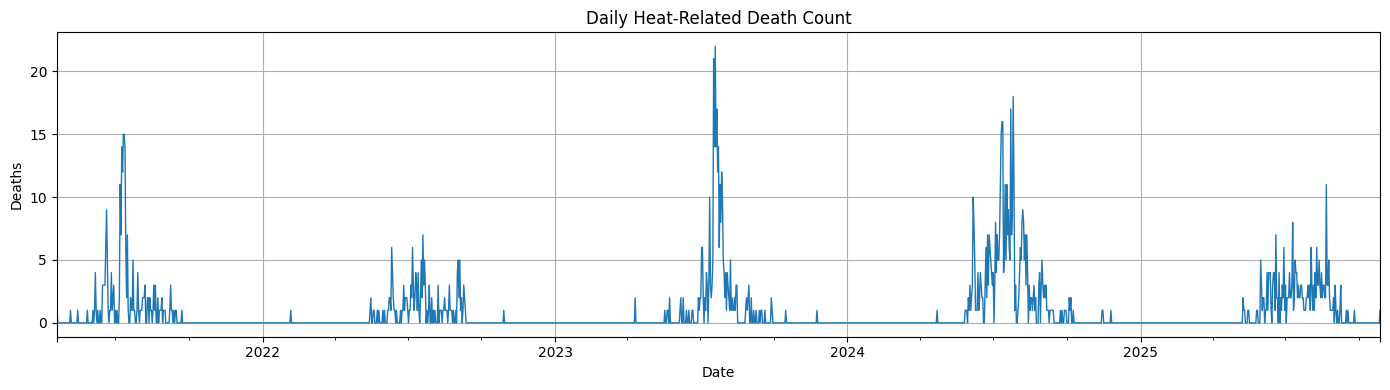

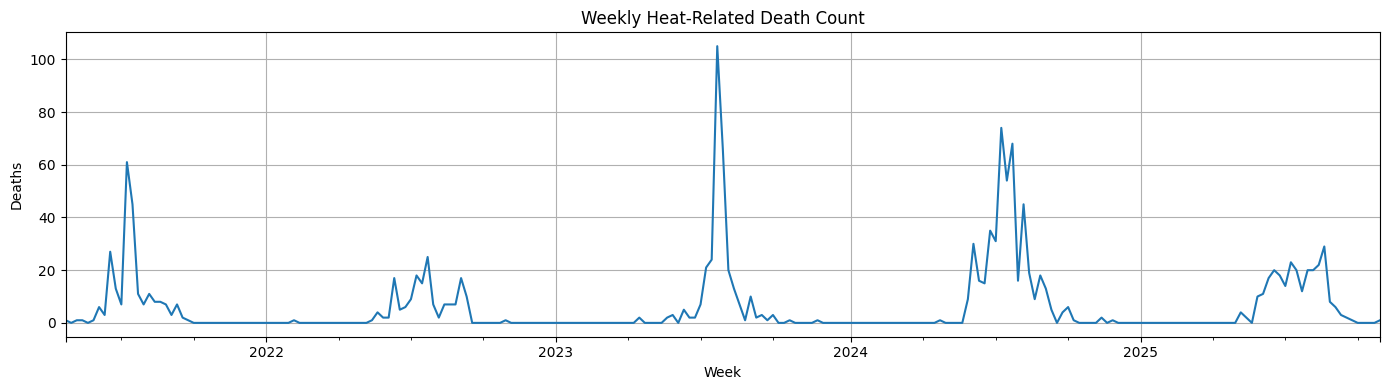

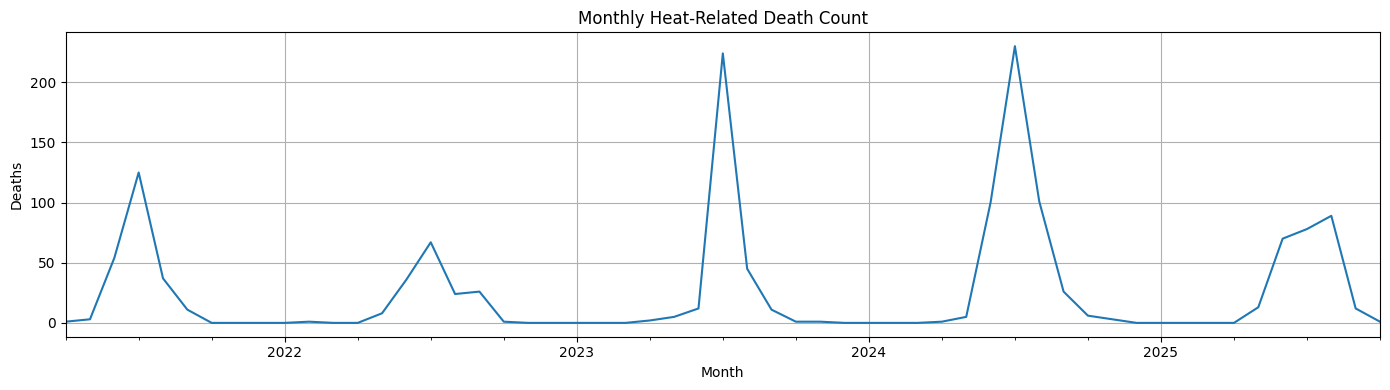

In [6]:
# Plot daily, weekly, and monthly counts
daily_heat_ts["heat_death_count"].plot(
    figsize=(14, 4),
    title="Daily Heat-Related Death Count",
    linewidth=1
)
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()

weekly_heat_ts["heat_death_count"].plot(
    figsize=(14, 4),
    title="Weekly Heat-Related Death Count",
    linewidth=1.5
)
plt.xlabel("Week")
plt.ylabel("Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()

monthly_heat_ts["heat_death_count"].plot(
    figsize=(14, 4),
    title="Monthly Heat-Related Death Count",
    linewidth=1.5
)
plt.xlabel("Month")
plt.ylabel("Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# Export reusable time series files
daily_path = BASE_DIR / "daily_heat_death_timeseries.csv"
weekly_path = BASE_DIR / "weekly_heat_death_timeseries.csv"
monthly_path = BASE_DIR / "monthly_heat_death_timeseries.csv"

daily_heat_ts.to_csv(daily_path)
weekly_heat_ts.to_csv(weekly_path)
monthly_heat_ts.to_csv(monthly_path)

print("Saved:")
print(daily_path)
print(weekly_path)
print(monthly_path)


Saved:
/Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/daily_heat_death_timeseries.csv
/Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/weekly_heat_death_timeseries.csv
/Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/monthly_heat_death_timeseries.csv


## 3. Optional: retrieve historical weather data

The uploaded heat-death files do not contain a complete daily weather table.

One file has a `Temperature` field, but it is case-level and only available for part of the data.  
That is not enough to represent weather for every day, including zero-death days.

The recommended approach is to retrieve historical weather by date and location, then merge it into the daily time series.  
This notebook uses Las Vegas coordinates as the default:

- Latitude: `36.1716`
- Longitude: `-115.1391`

Set `FETCH_WEATHER = True` to pull data from Open-Meteo when you have internet access.


In [8]:
FETCH_WEATHER = True

LATITUDE = 36.1716
LONGITUDE = -115.1391
TIMEZONE = "America/Los_Angeles"

weather_daily = None

if FETCH_WEATHER:
    try:
        import requests

        start_date = daily_heat_ts.index.min().strftime("%Y-%m-%d")
        end_date = daily_heat_ts.index.max().strftime("%Y-%m-%d")

        url = "https://archive-api.open-meteo.com/v1/archive"

        params = {
            "latitude": LATITUDE,
            "longitude": LONGITUDE,
            "start_date": start_date,
            "end_date": end_date,
            "daily": ",".join([
                "temperature_2m_max",
                "temperature_2m_min",
                "apparent_temperature_max",
                "apparent_temperature_min",
                "precipitation_sum",
                "rain_sum",
                "snowfall_sum",
                "wind_speed_10m_max",
                "shortwave_radiation_sum"
            ]),
            "temperature_unit": "fahrenheit",
            "wind_speed_unit": "mph",
            "precipitation_unit": "inch",
            "timezone": TIMEZONE,
        }

        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()

        weather_daily = pd.DataFrame(payload["daily"])
        weather_daily["date"] = pd.to_datetime(weather_daily["time"])
        weather_daily = weather_daily.drop(columns=["time"]).set_index("date").sort_index()

        weather_path = BASE_DIR / "las_vegas_daily_weather_open_meteo.csv"
        weather_daily.to_csv(weather_path)

        print(f"Retrieved weather from {start_date} to {end_date}")
        print(f"Saved weather data to: {weather_path}")
        display(weather_daily.head())

    except Exception as e:
        print("Weather retrieval failed. Continuing with calendar-only features.")
        print("Error:", e)
        weather_daily = None
else:
    print("Weather retrieval skipped.")


Retrieved weather from 2021-04-19 to 2025-10-27
Saved weather data to: /Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact/las_vegas_daily_weather_open_meteo.csv


,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,shortwave_radiation_sum
date,,,,,,,,,
2021-04-19,86.1,55.7,82.5,46.8,0.0,0.0,0.0,16.2,27.84
2021-04-20,86.3,61.1,79.5,53.5,0.0,0.0,0.0,15.8,26.94
2021-04-21,79.2,65.9,69.0,54.0,0.0,0.0,0.0,26.3,26.90
2021-04-22,79.9,55.0,73.9,49.0,0.0,0.0,0.0,12.8,26.98
2021-04-23,83.8,56.7,79.7,48.6,0.0,0.0,0.0,14.3,27.77


## 4. Merge heat-death counts with weather if available

If the weather API worked, the modeling dataset will include daily weather variables.  
If not, the model will use calendar/seasonality and lag features only.


In [9]:
daily_model_df = daily_heat_ts.copy()

if weather_daily is not None:
    daily_model_df = daily_model_df.merge(
        weather_daily,
        left_index=True,
        right_index=True,
        how="left"
    )

    # Weather should be continuous, but fill small gaps defensively.
    weather_cols = [c for c in weather_daily.columns if c in daily_model_df.columns]
    daily_model_df[weather_cols] = daily_model_df[weather_cols].ffill().bfill()

display(daily_model_df.head())
print(daily_model_df.columns.tolist())


,heat_death_count,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_max,shortwave_radiation_sum
date,,,,,,,,,,
2021-04-19,1,86.1,55.7,82.5,46.8,0.0,0.0,0.0,16.2,27.84
2021-04-20,0,86.3,61.1,79.5,53.5,0.0,0.0,0.0,15.8,26.94
2021-04-21,0,79.2,65.9,69.0,54.0,0.0,0.0,0.0,26.3,26.90
2021-04-22,0,79.9,55.0,73.9,49.0,0.0,0.0,0.0,12.8,26.98
2021-04-23,0,83.8,56.7,79.7,48.6,0.0,0.0,0.0,14.3,27.77


['heat_death_count', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum']


In [10]:
# Weekly aggregation:
# - Death counts are summed.
# - Weather variables are averaged or maximized depending on interpretation.

weekly_model_df = daily_model_df[["heat_death_count"]].resample("W-SUN").sum()

if weather_daily is not None:
    weather_cols = [c for c in weather_daily.columns if c in daily_model_df.columns]

    weekly_weather_mean = daily_model_df[weather_cols].resample("W-SUN").mean()
    weekly_weather_max = daily_model_df[[
        c for c in weather_cols
        if c.endswith("_max") or "temperature" in c or "wind_speed" in c
    ]].resample("W-SUN").max()

    weekly_weather_mean = weekly_weather_mean.add_suffix("_weekly_mean")
    weekly_weather_max = weekly_weather_max.add_suffix("_weekly_max")

    weekly_model_df = weekly_model_df.merge(
        weekly_weather_mean,
        left_index=True,
        right_index=True,
        how="left"
    ).merge(
        weekly_weather_max,
        left_index=True,
        right_index=True,
        how="left"
    )

display(weekly_model_df.head())
print("Weekly modeling columns:")
print(weekly_model_df.columns.tolist())


,heat_death_count,temperature_2m_max_weekly_mean,temperature_2m_min_weekly_mean,apparent_temperature_max_weekly_mean,apparent_temperature_min_weekly_mean,precipitation_sum_weekly_mean,rain_sum_weekly_mean,snowfall_sum_weekly_mean,wind_speed_10m_max_weekly_mean,shortwave_radiation_sum_weekly_mean,temperature_2m_max_weekly_max,temperature_2m_min_weekly_max,apparent_temperature_max_weekly_max,apparent_temperature_min_weekly_max,wind_speed_10m_max_weekly_max
date,,,,,,,,,,,,,,,
2021-04-25,1,83.100000,60.471429,74.971429,51.628571,0.000000,0.000000,0.0,19.214286,26.835714,86.4,65.9,82.5,56.8,26.3
2021-05-02,0,84.428571,60.642857,76.800000,52.571429,0.005000,0.005000,0.0,16.071429,24.595714,97.0,71.9,92.7,64.1,24.9
2021-05-09,1,90.514286,66.071429,84.028571,58.271429,0.000000,0.000000,0.0,15.371429,29.042857,98.4,71.3,93.5,65.2,21.3
2021-05-16,1,91.400000,68.271429,86.157143,61.171429,0.001714,0.001714,0.0,14.928571,28.734286,98.1,72.9,94.2,66.8,23.3
2021-05-23,0,83.571429,60.342857,76.014286,52.571429,0.001143,0.001143,0.0,18.971429,29.017143,96.9,71.0,93.4,65.2,29.9


Weekly modeling columns:
['heat_death_count', 'temperature_2m_max_weekly_mean', 'temperature_2m_min_weekly_mean', 'apparent_temperature_max_weekly_mean', 'apparent_temperature_min_weekly_mean', 'precipitation_sum_weekly_mean', 'rain_sum_weekly_mean', 'snowfall_sum_weekly_mean', 'wind_speed_10m_max_weekly_mean', 'shortwave_radiation_sum_weekly_mean', 'temperature_2m_max_weekly_max', 'temperature_2m_min_weekly_max', 'apparent_temperature_max_weekly_max', 'apparent_temperature_min_weekly_max', 'wind_speed_10m_max_weekly_max']


## 5. Feature engineering

We add:

- Seasonal features using week-of-year sine/cosine
- Summer/heat season indicator
- Lagged heat-death counts
- Rolling historical average

Lag and rolling features use previous weeks only to avoid data leakage.


In [11]:
model_df = weekly_model_df.copy()

model_df["weekofyear"] = model_df.index.isocalendar().week.astype(int)
model_df["month"] = model_df.index.month
model_df["year"] = model_df.index.year

# Cyclical seasonality
model_df["week_sin"] = np.sin(2 * np.pi * model_df["weekofyear"] / 52.0)
model_df["week_cos"] = np.cos(2 * np.pi * model_df["weekofyear"] / 52.0)

# Heat season indicator
model_df["summer_peak"] = model_df["month"].isin([6, 7, 8, 9]).astype(int)

# Lag features
model_df["lag_1_week"] = model_df["heat_death_count"].shift(1)
model_df["rolling_4_week_avg"] = (
    model_df["heat_death_count"]
    .shift(1)
    .rolling(4, min_periods=2)
    .mean()
)

model_df = model_df.dropna().copy()

display(model_df.head())
print("Modeling rows:", len(model_df))


,heat_death_count,temperature_2m_max_weekly_mean,temperature_2m_min_weekly_mean,apparent_temperature_max_weekly_mean,apparent_temperature_min_weekly_mean,precipitation_sum_weekly_mean,rain_sum_weekly_mean,snowfall_sum_weekly_mean,wind_speed_10m_max_weekly_mean,shortwave_radiation_sum_weekly_mean,temperature_2m_max_weekly_max,temperature_2m_min_weekly_max,apparent_temperature_max_weekly_max,apparent_temperature_min_weekly_max,wind_speed_10m_max_weekly_max,weekofyear,month,year,week_sin,week_cos,summer_peak,lag_1_week,rolling_4_week_avg
date,,,,,,,,,,,,,,,,,,,,,,,
2021-05-09,1,90.514286,66.071429,84.028571,58.271429,0.000000,0.000000,0.0,15.371429,29.042857,98.4,71.3,93.5,65.2,21.3,18,5,2021,0.822984,-0.568065,0,0.0,0.500000
2021-05-16,1,91.400000,68.271429,86.157143,61.171429,0.001714,0.001714,0.0,14.928571,28.734286,98.1,72.9,94.2,66.8,23.3,19,5,2021,0.748511,-0.663123,0,1.0,0.666667
2021-05-23,0,83.571429,60.342857,76.014286,52.571429,0.001143,0.001143,0.0,18.971429,29.017143,96.9,71.0,93.4,65.2,29.9,20,5,2021,0.663123,-0.748511,0,1.0,0.750000
2021-05-30,1,94.000000,68.400000,89.771429,61.585714,0.000000,0.000000,0.0,11.500000,28.005714,98.1,72.8,95.9,65.5,20.2,21,5,2021,0.568065,-0.822984,0,0.0,0.500000
2021-06-06,6,105.171429,78.642857,101.271429,72.671429,0.000000,0.000000,0.0,13.971429,29.325714,109.2,81.8,105.9,77.0,18.2,22,6,2021,0.464723,-0.885456,1,1.0,0.750000


Modeling rows: 235


## 6. Fit Poisson and Negative Binomial models

Count data often starts with Poisson regression.

However, if the data is overdispersed, meaning variance is much larger than the mean, Negative Binomial is usually a better fit.

This model uses a chronological train/test split.


In [12]:
target = "heat_death_count"

base_features = [
    "week_sin",
    "week_cos",
    "summer_peak",
    "lag_1_week",
    "rolling_4_week_avg",
]

# Add weather features only if they exist.
weather_feature_candidates = [
    "temperature_2m_max_weekly_mean",
    "apparent_temperature_max_weekly_mean",
    "temperature_2m_max_weekly_max",
    "apparent_temperature_max_weekly_max",
    "precipitation_sum_weekly_mean",
    "wind_speed_10m_max_weekly_mean",
    "shortwave_radiation_sum_weekly_mean",
]

weather_features = [c for c in weather_feature_candidates if c in model_df.columns]

features = base_features + weather_features

print("Using features:")
for f in features:
    print("-", f)

X = sm.add_constant(model_df[features])
y = model_df[target]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Train period: {y_train.index.min().date()} to {y_train.index.max().date()}")
print(f"Test period:  {y_test.index.min().date()} to {y_test.index.max().date()}")
print(f"Train rows: {len(y_train)}, Test rows: {len(y_test)}")


Using features:
- week_sin
- week_cos
- summer_peak
- lag_1_week
- rolling_4_week_avg
- temperature_2m_max_weekly_mean
- apparent_temperature_max_weekly_mean
- temperature_2m_max_weekly_max
- apparent_temperature_max_weekly_max
- precipitation_sum_weekly_mean
- wind_speed_10m_max_weekly_mean
- shortwave_radiation_sum_weekly_mean
Train period: 2021-05-09 to 2024-12-08
Test period:  2024-12-15 to 2025-11-02
Train rows: 188, Test rows: 47


In [13]:
# Baseline: predict this week's deaths using the previous week's count.
baseline_pred = X_test["lag_1_week"].clip(lower=0)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = rmse(y_test, baseline_pred)

print("Baseline model")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)


Baseline model
MAE: 2.148936170212766
RMSE: 4.421899081770377


In [14]:
# Poisson GLM
poisson_model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Poisson()
).fit()

poisson_pred = poisson_model.predict(X_test).clip(lower=0)

poisson_mae = mean_absolute_error(y_test, poisson_pred)
poisson_rmse = rmse(y_test, poisson_pred)

dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid

print(poisson_model.summary())
print("\nPoisson performance")
print("MAE:", poisson_mae)
print("RMSE:", poisson_rmse)
print("Overdispersion ratio:", dispersion)

if dispersion > 1.5:
    print("\nInterpretation: The series appears overdispersed, so Negative Binomial is likely more appropriate than Poisson.")
else:
    print("\nInterpretation: Overdispersion is not severe; Poisson may be acceptable.")


                 Generalized Linear Model Regression Results                  
Dep. Variable:       heat_death_count   No. Observations:                  188
Model:                            GLM   Df Residuals:                      175
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -298.20
Date:                Thu, 14 May 2026   Deviance:                       280.51
Time:                        22:04:20   Pearson chi2:                 1.26e+03
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [15]:
# Negative Binomial model
# We first try statsmodels' discrete NegativeBinomial, which estimates overdispersion.
# If it fails, we fall back to GLM NegativeBinomial.

try:
    nb_model = sm.NegativeBinomial(y_train, X_train).fit(disp=False, maxiter=500)
    nb_pred = nb_model.predict(X_test).clip(lower=0)
    nb_model_type = "Discrete NegativeBinomial"

except Exception as e:
    print("Discrete NegativeBinomial failed, falling back to GLM NegativeBinomial.")
    print("Error:", e)

    nb_model = sm.GLM(
        y_train,
        X_train,
        family=sm.families.NegativeBinomial()
    ).fit()

    nb_pred = nb_model.predict(X_test).clip(lower=0)
    nb_model_type = "GLM NegativeBinomial"

nb_mae = mean_absolute_error(y_test, nb_pred)
nb_rmse = rmse(y_test, nb_pred)

print(nb_model_type)
print(nb_model.summary())
print("\nNegative Binomial performance")
print("MAE:", nb_mae)
print("RMSE:", nb_rmse)


Discrete NegativeBinomial
                     NegativeBinomial Regression Results                      
Dep. Variable:       heat_death_count   No. Observations:                  188
Model:               NegativeBinomial   Df Residuals:                      175
Method:                           MLE   Df Model:                           12
Date:                Thu, 14 May 2026   Pseudo R-squ.:                     nan
Time:                        22:04:20   Log-Likelihood:                    nan
converged:                      False   LL-Null:                       -422.23
Covariance Type:            nonrobust   LLR p-value:                       nan
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                  -15.5824        nan        nan        nan         nan         nan
week_sin                   

/Users/chrispapesh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/chrispapesh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [16]:
results = pd.DataFrame({
    "actual": y_test,
    "baseline_lag_1_week": baseline_pred,
    "poisson_pred": poisson_pred,
    "negative_binomial_pred": nb_pred,
})

display(results.head(20))

metrics = pd.DataFrame({
    "model": ["Baseline lag-1 week", "Poisson", "Negative Binomial"],
    "MAE": [baseline_mae, poisson_mae, nb_mae],
    "RMSE": [baseline_rmse, poisson_rmse, nb_rmse],
})

display(metrics)


,actual,baseline_lag_1_week,poisson_pred,negative_binomial_pred
date,,,,
2024-12-15,0,0.0,0.002252,0.002252
2024-12-22,0,0.0,0.007608,0.007608
2024-12-29,0,0.0,0.006526,0.006526
2025-01-05,0,0.0,0.004988,0.004988
2025-01-12,0,0.0,0.004012,0.004012
2025-01-19,0,0.0,0.001854,0.001854
2025-01-26,0,0.0,0.001290,0.001290
2025-02-02,0,0.0,0.005580,0.005580
2025-02-09,0,0.0,0.050196,0.050196


,model,MAE,RMSE
0,Baseline lag-1 week,2.148936,4.421899
1,Poisson,1.978031,3.852701
2,Negative Binomial,1.978031,3.852701


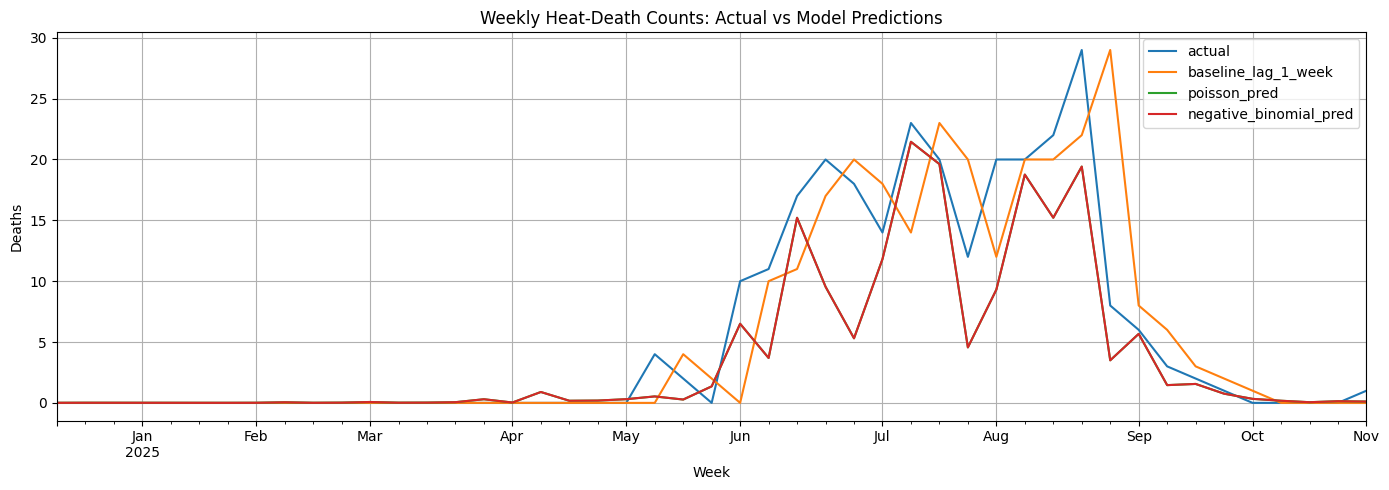

In [17]:
# Plot actual vs predictions
results.plot(
    figsize=(14, 5),
    title="Weekly Heat-Death Counts: Actual vs Model Predictions",
    linewidth=1.5
)

plt.xlabel("Week")
plt.ylabel("Deaths")
plt.grid(True)
plt.tight_layout()
plt.show()


## 7. Interpret model coefficients

For count models, exponentiated coefficients are incidence rate ratios.

Example:

- IRR greater than 1 means the feature is associated with higher expected heat-death counts.
- IRR less than 1 means the feature is associated with lower expected heat-death counts.

For lag/rolling features, interpretation should be cautious because they capture temporal clustering and seasonality.


In [18]:
def coefficient_table(model, model_name):
    params = model.params
    conf = model.conf_int()

    out = pd.DataFrame({
        "coefficient": params,
        "IRR": np.exp(params),
        "CI_lower_IRR": np.exp(conf[0]),
        "CI_upper_IRR": np.exp(conf[1]),
    })

    out["model"] = model_name
    return out

poisson_coef = coefficient_table(poisson_model, "Poisson")
nb_coef = coefficient_table(nb_model, "Negative Binomial")

display(poisson_coef)
display(nb_coef)


,coefficient,IRR,CI_lower_IRR,CI_upper_IRR,model
const,-15.582396,1.708644e-07,1.868083e-08,0.000002,Poisson
week_sin,0.397393,1.487940e+00,1.011479e+00,2.188839,Poisson
week_cos,-0.153044,8.580920e-01,3.762119e-01,1.957200,Poisson
summer_peak,0.274629,1.316042e+00,8.025552e-01,2.158067,Poisson
lag_1_week,0.003518,1.003525e+00,1.000233e+00,1.006827,Poisson
rolling_4_week_avg,0.011662,1.011731e+00,1.005987e+00,1.017507,Poisson
temperature_2m_max_weekly_mean,0.126139,1.134440e+00,1.069769e+00,1.203021,Poisson
apparent_temperature_max_weekly_mean,-0.004125,9.958834e-01,9.452518e-01,1.049227,Poisson
temperature_2m_max_weekly_max,0.012769,1.012851e+00,9.711759e-01,1.056314,Poisson
apparent_temperature_max_weekly_max,0.044833,1.045854e+00,1.004646e+00,1.088752,Poisson


,coefficient,IRR,CI_lower_IRR,CI_upper_IRR,model
const,-15.582396,1.708644e-07,NaN,NaN,Negative Binomial
week_sin,0.397393,1.487940e+00,NaN,NaN,Negative Binomial
week_cos,-0.153044,8.580920e-01,NaN,NaN,Negative Binomial
summer_peak,0.274629,1.316042e+00,NaN,NaN,Negative Binomial
lag_1_week,0.003518,1.003525e+00,NaN,NaN,Negative Binomial
rolling_4_week_avg,0.011662,1.011731e+00,NaN,NaN,Negative Binomial
temperature_2m_max_weekly_mean,0.126139,1.134440e+00,NaN,NaN,Negative Binomial
apparent_temperature_max_weekly_mean,-0.004125,9.958834e-01,NaN,NaN,Negative Binomial
temperature_2m_max_weekly_max,0.012769,1.012851e+00,NaN,NaN,Negative Binomial
apparent_temperature_max_weekly_max,0.044833,1.045854e+00,NaN,NaN,Negative Binomial
